<a href="https://colab.research.google.com/github/himanshubhimte69/Parameter_Efficient_Deep_Learning-Class_Selective_Knowledge_Distillation_for_Precision_Agriculture/blob/main/GradCam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# GRAD-CAM VISUALIZATION
# BASELINE vs KD STUDENT
# ============================================================

import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense
)

In [ ]:
# ============================================================
# 2. CREATE IMAGE FOLDER
# ============================================================

test_folder = "/content/gradcam_images"

os.makedirs(test_folder, exist_ok=True)

print("Upload difficult test images into:")
print(test_folder)

Upload difficult test images into:
/content/gradcam_images


In [ ]:
# ============================================================
# 3. UPLOAD IMAGES
# ============================================================

from google.colab import files
import shutil

uploaded = files.upload()

for file_name in uploaded.keys():

    shutil.move(
        file_name,
        os.path.join(test_folder, file_name)
    )

print("Images uploaded successfully")


Saving Train_26.jpg to Train_26.jpg
Saving Train_29.jpg to Train_29.jpg
Saving Train_46.jpg to Train_46.jpg
Saving Train_83.jpg to Train_83.jpg
Saving Train_97.jpg to Train_97.jpg
Images uploaded successfully


In [ ]:
# ============================================================
# 4. CLASS NAMES
# ============================================================

class_names = [
    "healthy",
    "rust",
    "scab"
]

In [ ]:
# ============================================================
# 5. IMAGE SETTINGS
# ============================================================

IMG_SIZE = 380

# ============================================================
# 6. LOAD BASELINE MODEL
# ============================================================

baseline_base = EfficientNetB4(
    weights=None,
    include_top=False,
    input_shape=(380,380,3)
)

x = GlobalAveragePooling2D()(baseline_base.output)

baseline_output = Dense(
    3,
    activation='softmax'
)(x)

baseline_model = Model(
    inputs=baseline_base.input,
    outputs=baseline_output
)

baseline_model.load_weights(
    "/content/basemodel_model_pp2020.h5",
    by_name=True,
    skip_mismatch=True
)

print("Baseline model loaded successfully")

Baseline model loaded successfully


In [ ]:
# ============================================================
# LOAD KD STUDENT MODEL CORRECTLY
# ============================================================

from tensorflow.keras.applications import EfficientNetB4

student_base = EfficientNetB4(
    include_top=False,
    weights=None,
    input_shape=(380,380,3)
)

student_model_pp2020 = tf.keras.Sequential([
    student_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(
        3,
        activation='softmax'
    )
])

# IMPORTANT
student_model_pp2020.build(
    (None,380,380,3)
)

student_model_pp2020.load_weights(
    "/content/student_model_pp2020.h5"
)

print("KD Student Loaded Successfully")

KD Student Loaded Successfully


In [ ]:
# ============================================================
# 8. LAST CONVOLUTIONAL LAYER
# ============================================================

LAST_CONV_LAYER = "top_conv"

# ============================================================
# 9. GRAD-CAM FUNCTION
# ============================================================

def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
):

    grad_model = Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()


In [ ]:
# ============================================================
# 10. HEATMAP OVERLAY FUNCTION
# ============================================================

def overlay_heatmap(
    heatmap,
    original_image,
    alpha=0.4
):

    heatmap = cv2.resize(
        heatmap,
        (
            original_image.shape[1],
            original_image.shape[0]
        )
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    superimposed_img = cv2.addWeighted(
        original_image,
        1-alpha,
        heatmap,
        alpha,
        0
    )

    return superimposed_img


In [ ]:
# ============================================================
# 11. OUTPUT DIRECTORY
# ============================================================

save_dir = "/content/gradcam_results"

os.makedirs(save_dir, exist_ok=True)


In [ ]:
# ============================================================
# 12. IMAGE FILES
# ============================================================

image_files = [
    f for f in os.listdir(test_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"\nFound {len(image_files)} images")



Found 5 images



Processing: Train_46.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 380, 380, 3))
  warnings.warn(msg)


KD GradCAM failed: No such layer: top_conv. Existing layers are: ['efficientnetb4', 'global_average_pooling2d_2', 'dense_2'].
Saved: /content/gradcam_results/gradcam_Train_46.jpg


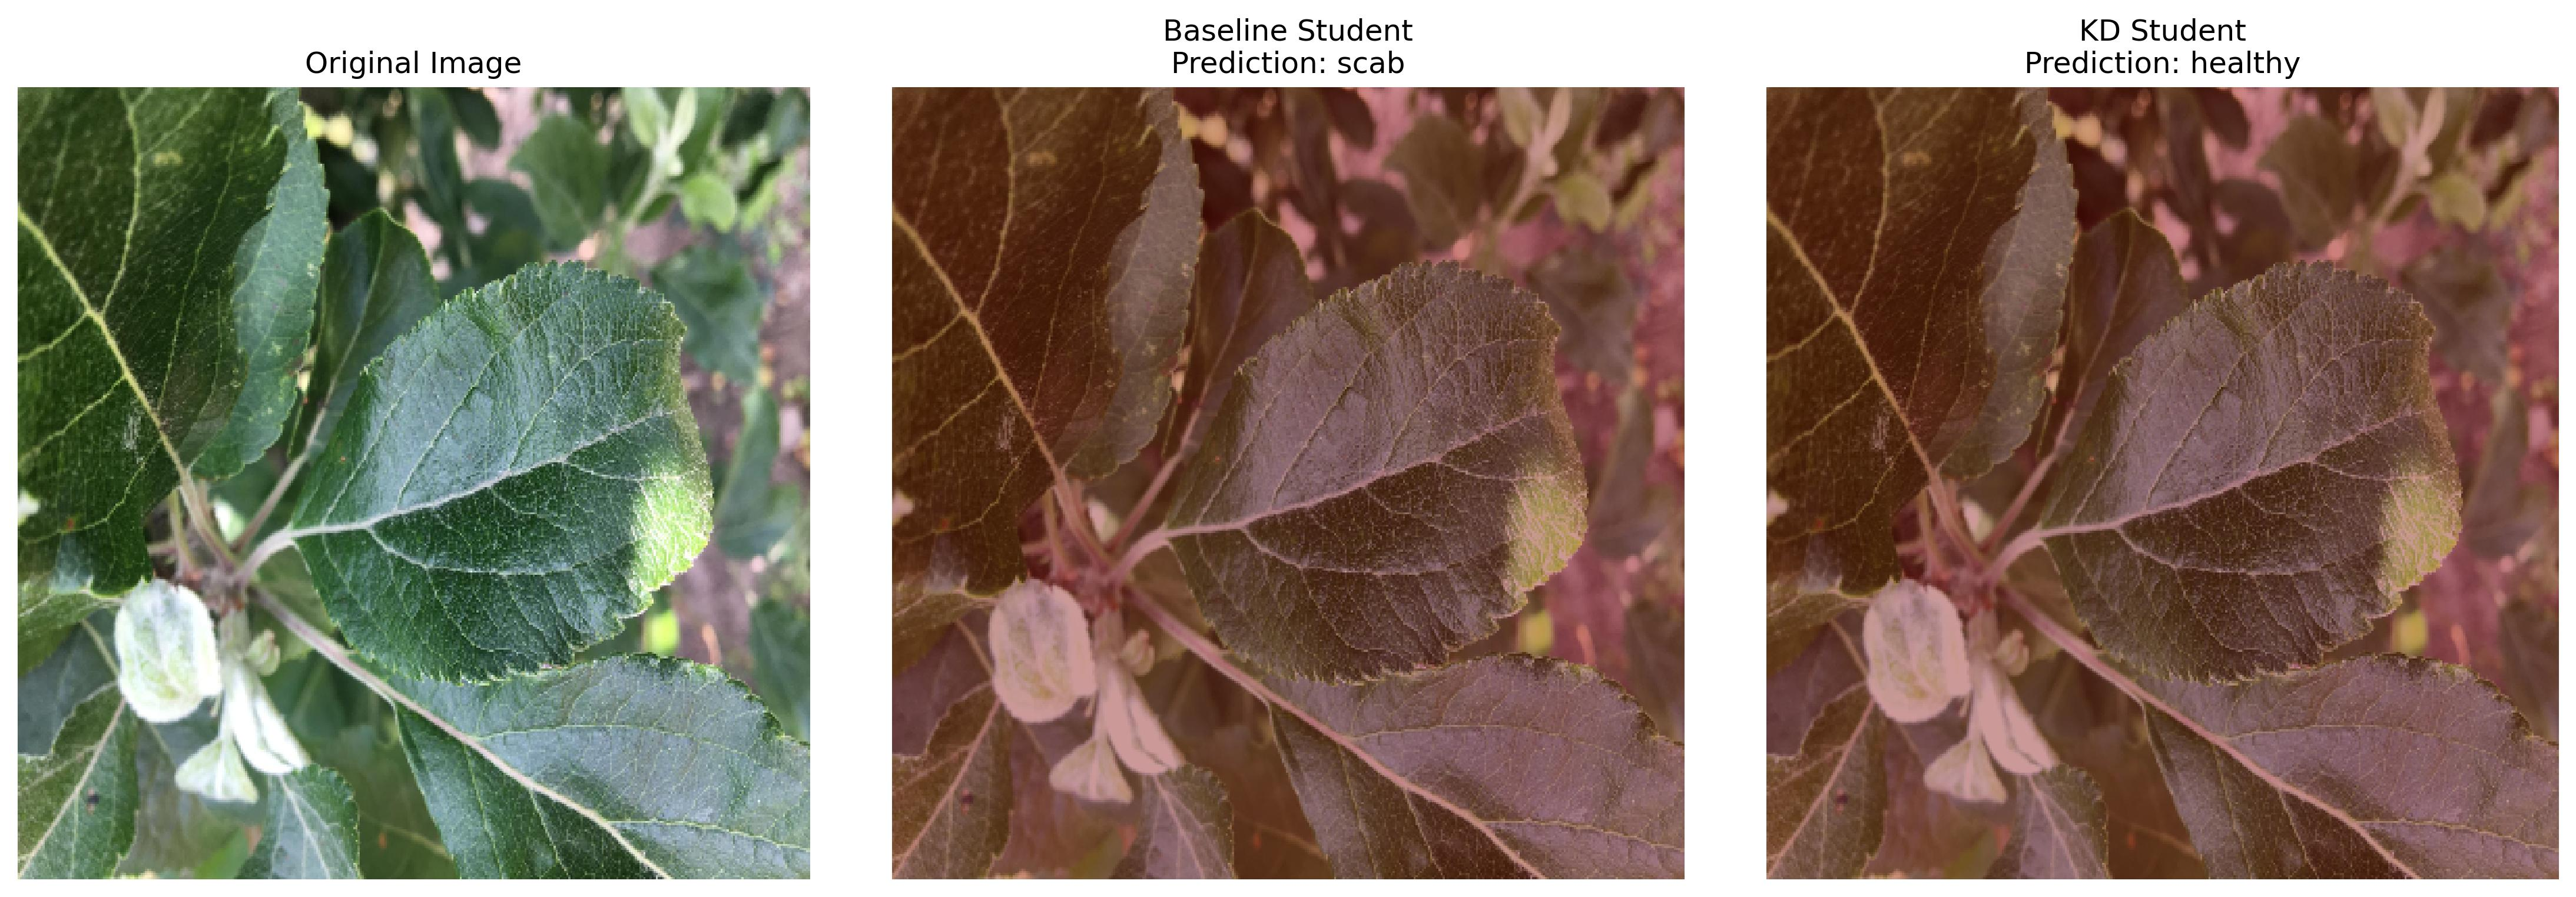


Processing: Train_26.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 380, 380, 3))
  warnings.warn(msg)


KD GradCAM failed: No such layer: top_conv. Existing layers are: ['efficientnetb4', 'global_average_pooling2d_2', 'dense_2'].
Saved: /content/gradcam_results/gradcam_Train_26.jpg


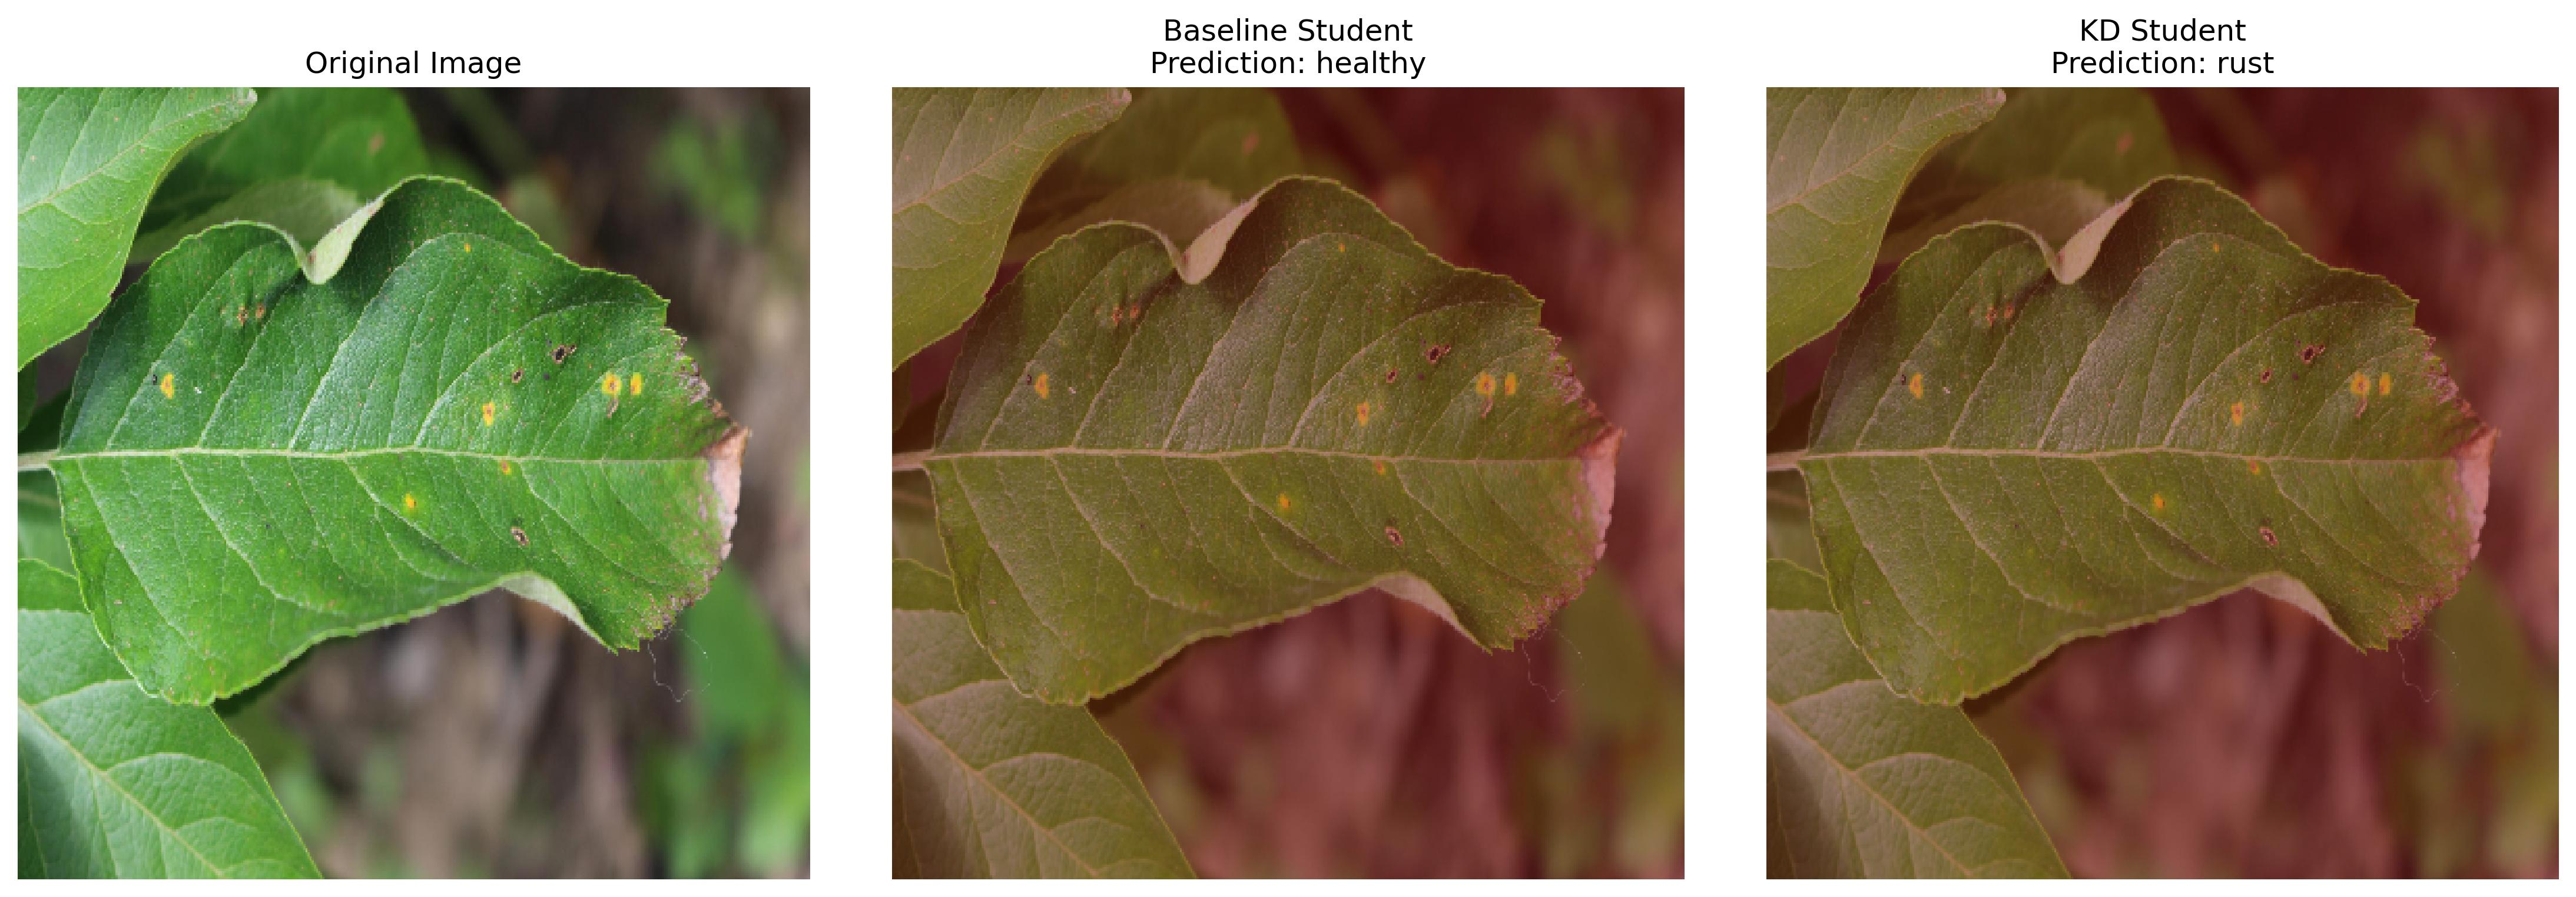


Processing: Train_97.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 380, 380, 3))
  warnings.warn(msg)


KD GradCAM failed: No such layer: top_conv. Existing layers are: ['efficientnetb4', 'global_average_pooling2d_2', 'dense_2'].
Saved: /content/gradcam_results/gradcam_Train_97.jpg


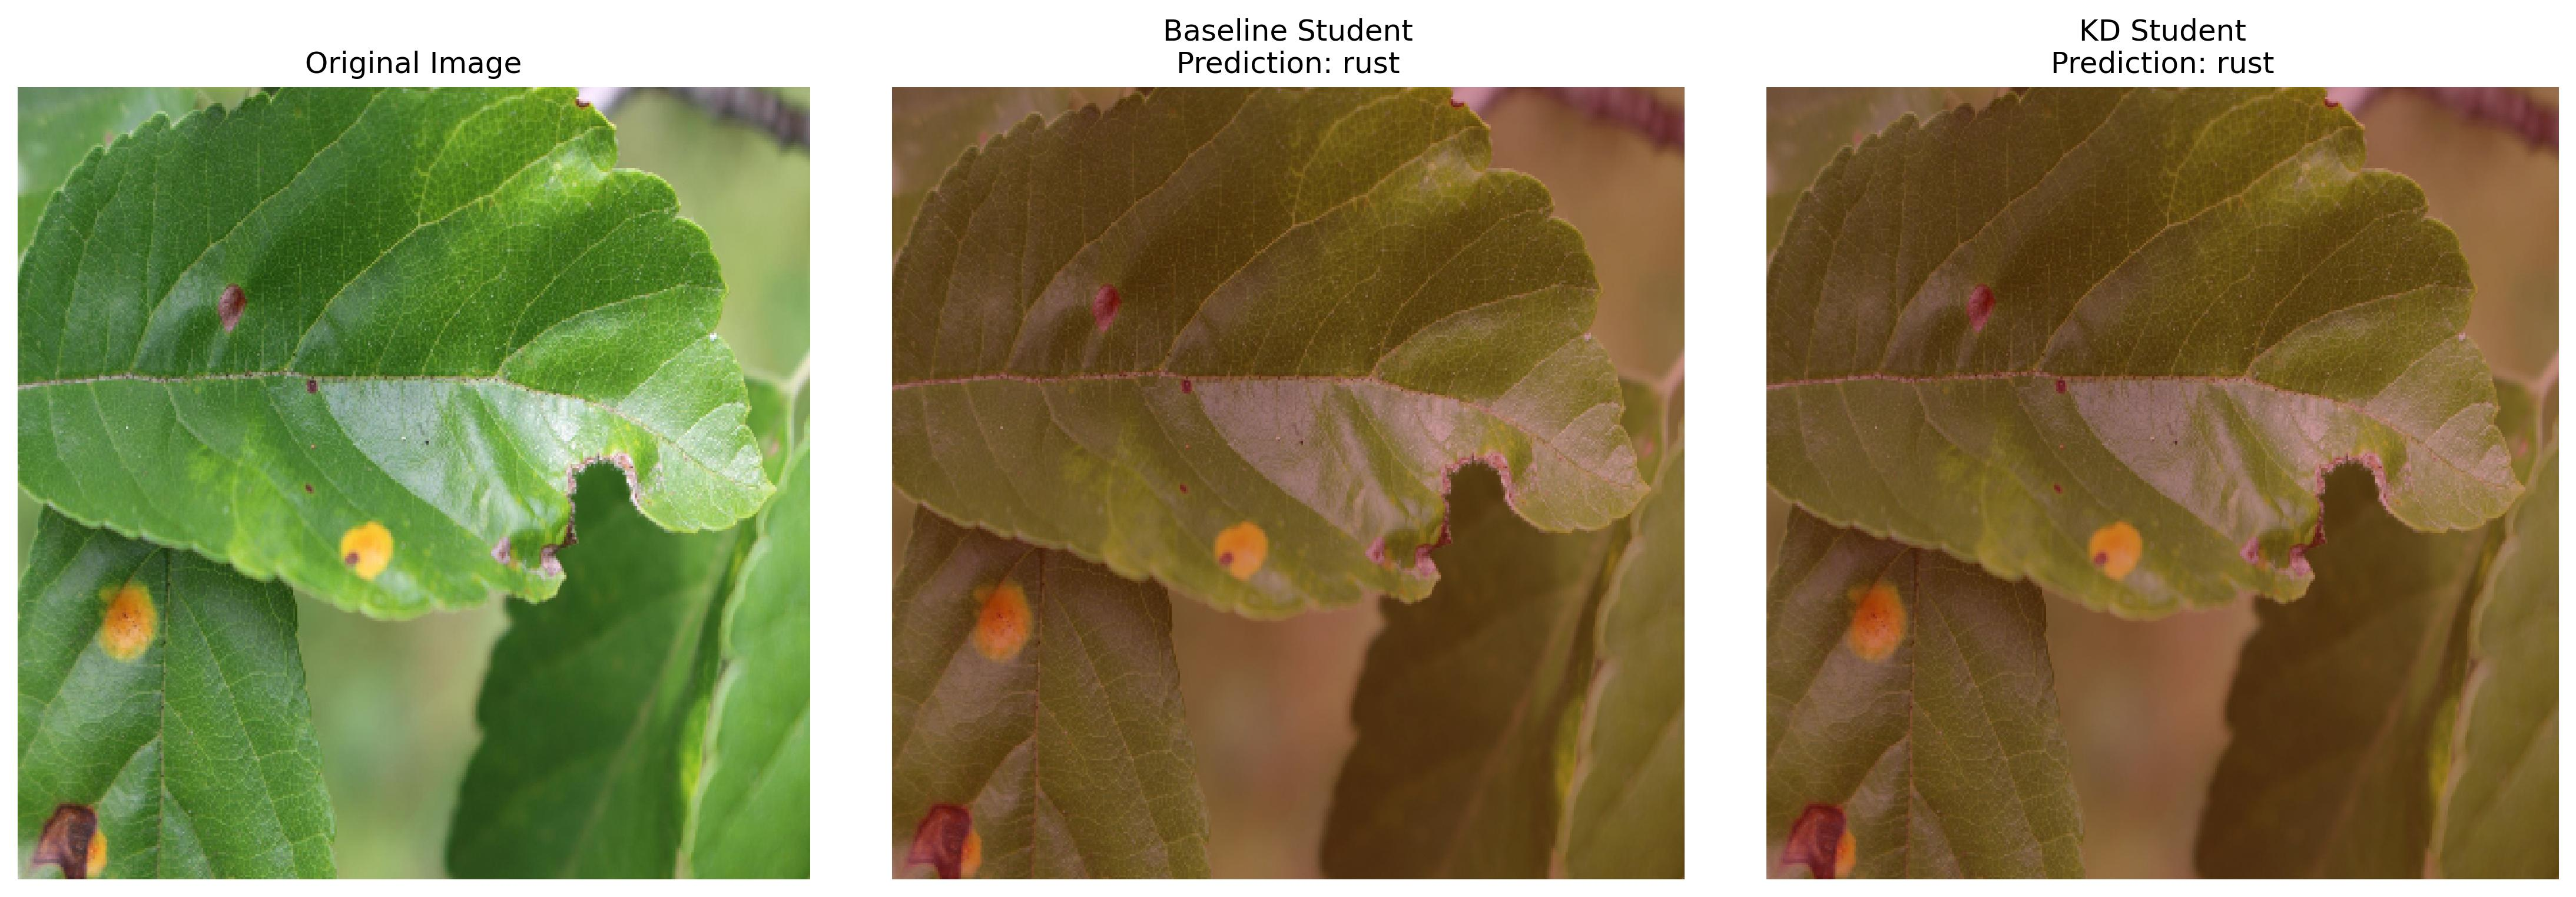


Processing: Train_83.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 380, 380, 3))
  warnings.warn(msg)


KD GradCAM failed: No such layer: top_conv. Existing layers are: ['efficientnetb4', 'global_average_pooling2d_2', 'dense_2'].
Saved: /content/gradcam_results/gradcam_Train_83.jpg


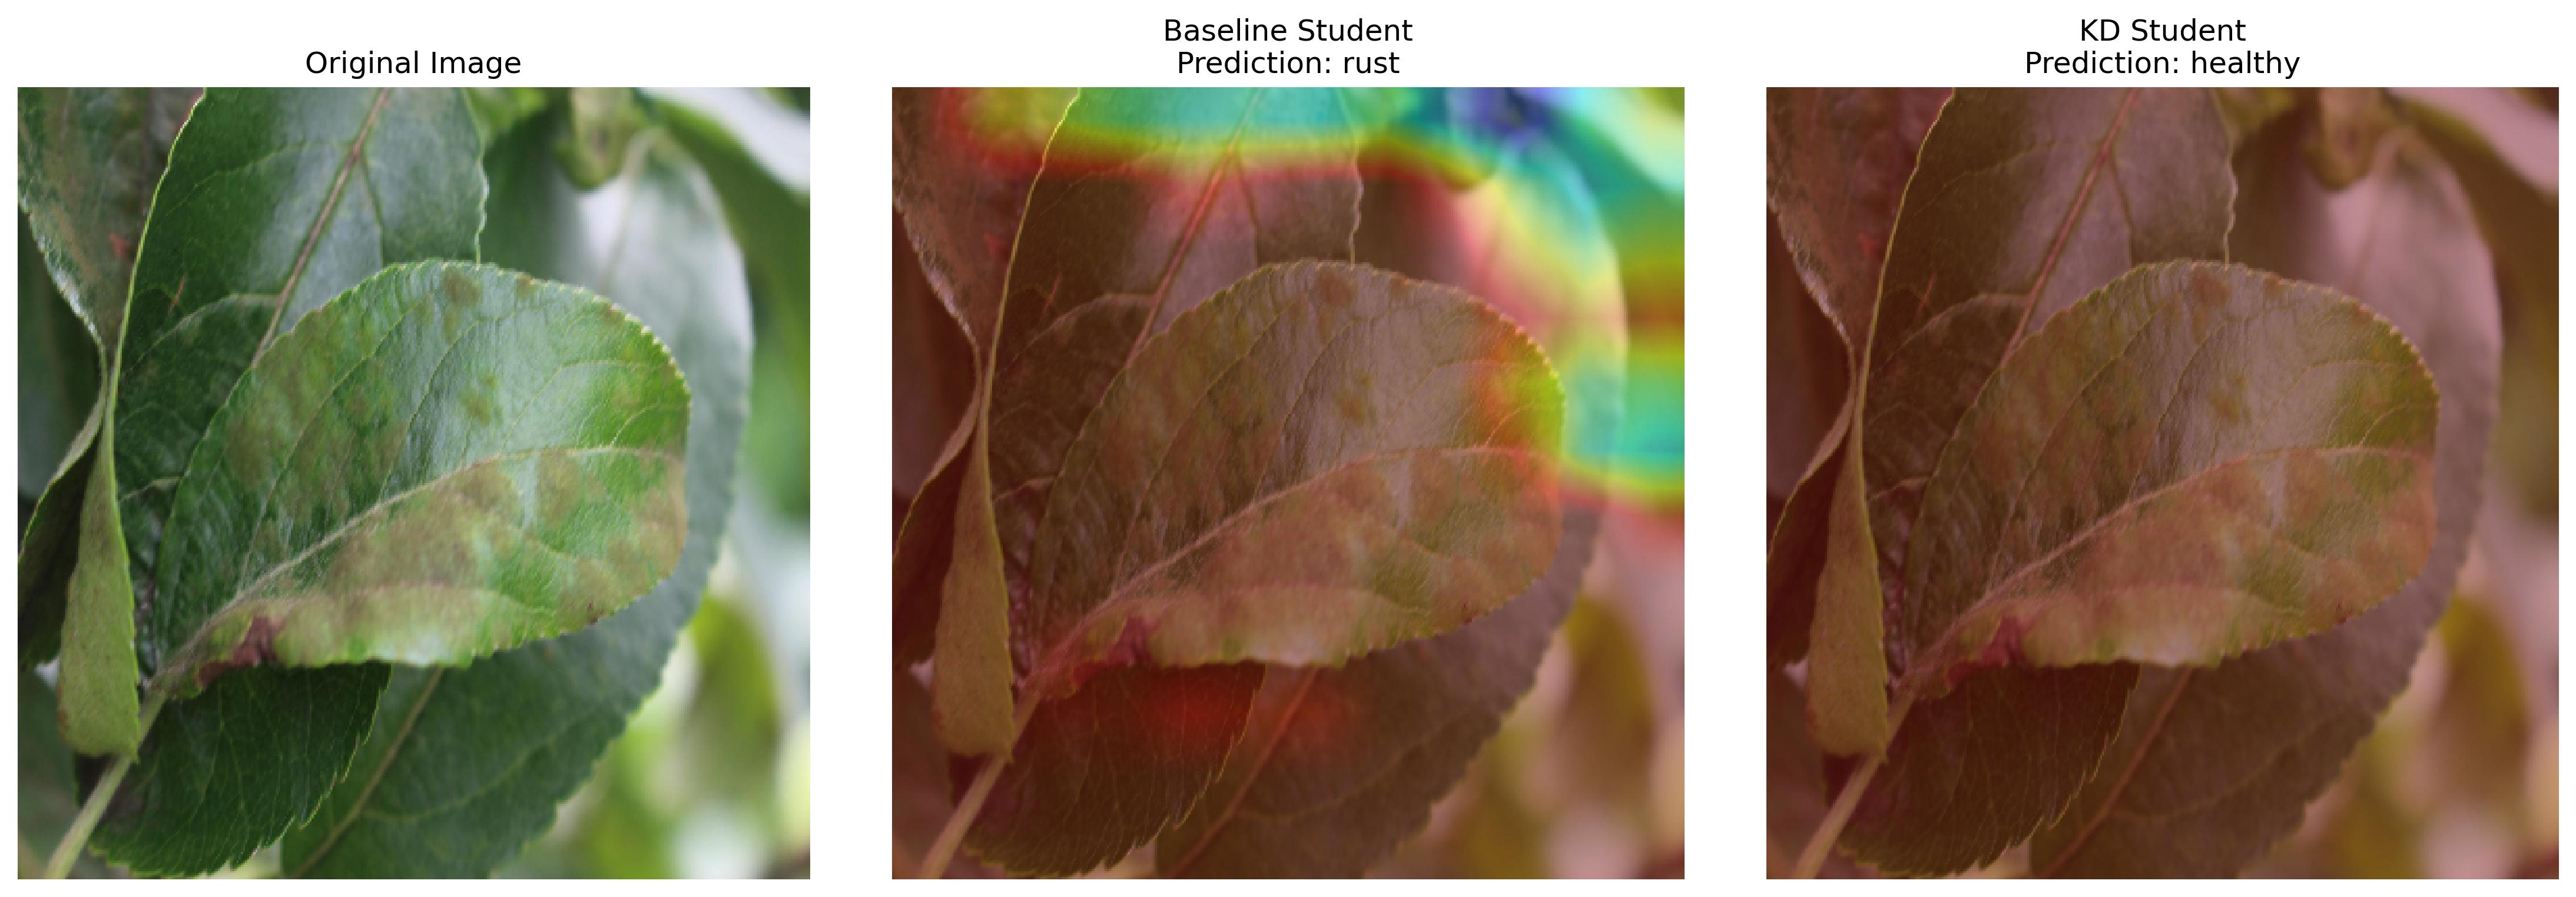


Processing: Train_29.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 380, 380, 3))
  warnings.warn(msg)


KD GradCAM failed: No such layer: top_conv. Existing layers are: ['efficientnetb4', 'global_average_pooling2d_2', 'dense_2'].
Saved: /content/gradcam_results/gradcam_Train_29.jpg


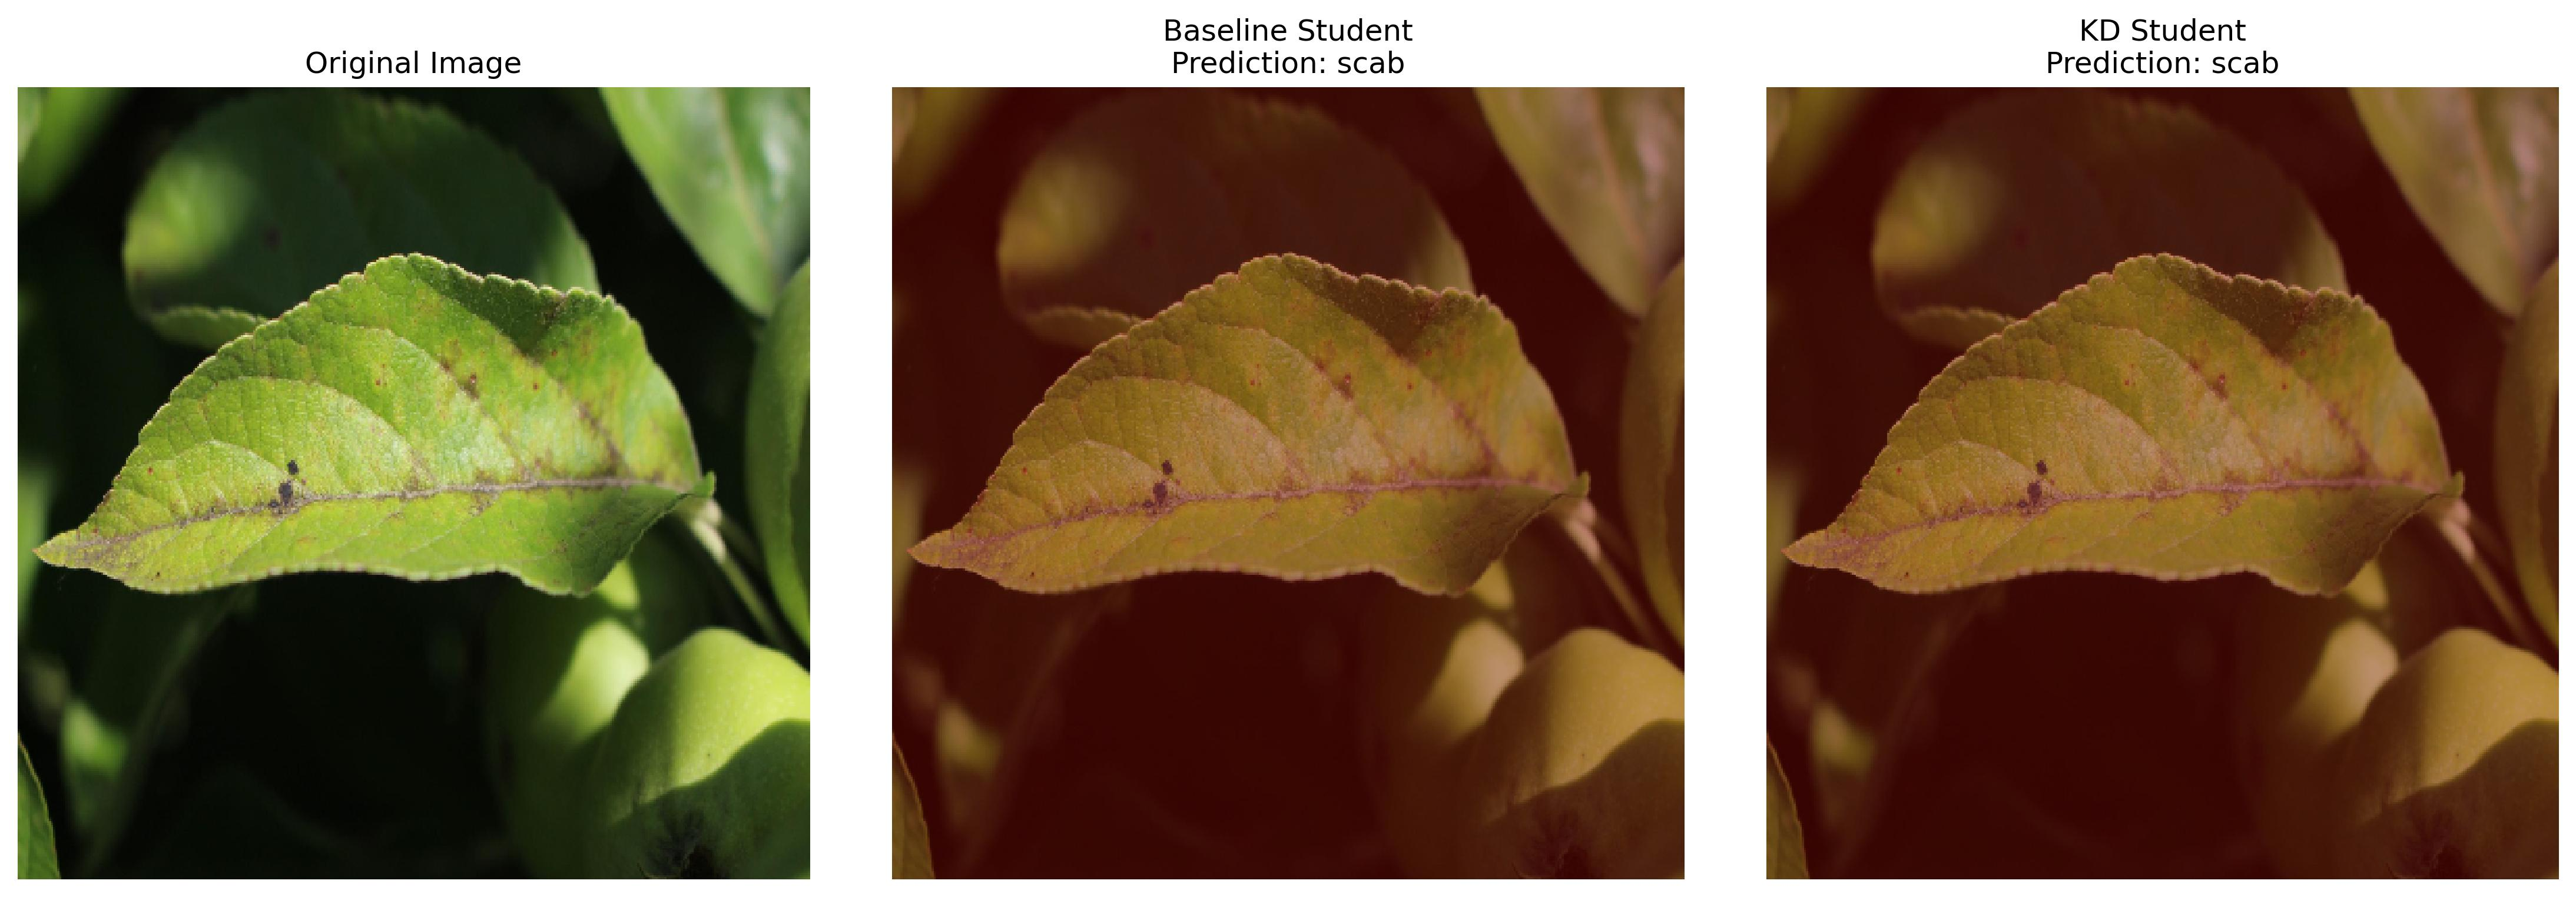


ALL GRAD-CAM VISUALIZATIONS COMPLETED


In [ ]:
# ============================================================
# 13. PROCESS ALL IMAGES
# ============================================================

from IPython.display import Image, display

for file_name in image_files:

    print(f"\nProcessing: {file_name}")

    img_path = os.path.join(
        test_folder,
        file_name
    )

    # --------------------------------------------------------
    # LOAD IMAGE
    # --------------------------------------------------------

    img = image.load_img(
        img_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = image.img_to_array(img)

    input_image = np.expand_dims(
        img_array,
        axis=0
    )

    input_image = preprocess_input(input_image)

    # --------------------------------------------------------
    # ORIGINAL IMAGE
    # --------------------------------------------------------

    original_img = cv2.imread(img_path)

    original_img = cv2.cvtColor(
        original_img,
        cv2.COLOR_BGR2RGB
    )

    original_img = cv2.resize(
        original_img,
        (IMG_SIZE, IMG_SIZE)
    )

    # --------------------------------------------------------
    # GENERATE HEATMAPS
    # --------------------------------------------------------

    try:

        baseline_heatmap = make_gradcam_heatmap(
            input_image,
            baseline_model,
            LAST_CONV_LAYER
        )

        baseline_heatmap = np.nan_to_num(
            baseline_heatmap
        )

    except Exception as e:

        print(f"Baseline GradCAM failed: {e}")

        baseline_heatmap = np.zeros((12,12))

    try:

        kd_heatmap = make_gradcam_heatmap(
            input_image,
            student_model_pp2020,
            LAST_CONV_LAYER
        )

        kd_heatmap = np.nan_to_num(
            kd_heatmap
        )

    except Exception as e:

        print(f"KD GradCAM failed: {e}")

        kd_heatmap = np.zeros((12,12))

    # --------------------------------------------------------
    # OVERLAY HEATMAPS
    # --------------------------------------------------------

    baseline_overlay = overlay_heatmap(
        baseline_heatmap,
        original_img
    )

    kd_overlay = overlay_heatmap(
        kd_heatmap,
        original_img
    )

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    baseline_pred = baseline_model.predict(
        input_image,
        verbose=0
    )

    kd_pred = student_model_pp2020.predict(
        input_image,
        verbose=0
    )

    baseline_class = class_names[
        np.argmax(baseline_pred)
    ]

    kd_class = class_names[
        np.argmax(kd_pred)
    ]

    # --------------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------------

    fig = plt.figure(figsize=(15,5))

    # --------------------------------------------------------
    # ORIGINAL IMAGE
    # --------------------------------------------------------

    plt.subplot(1,3,1)

    plt.imshow(original_img)

    plt.title("Original Image")

    plt.axis("off")

    # --------------------------------------------------------
    # BASELINE STUDENT
    # --------------------------------------------------------

    plt.subplot(1,3,2)

    plt.imshow(baseline_overlay)

    plt.title(
        f"Baseline Student\nPrediction: {baseline_class}"
    )

    plt.axis("off")

    # --------------------------------------------------------
    # KD STUDENT
    # --------------------------------------------------------

    plt.subplot(1,3,3)

    plt.imshow(kd_overlay)

    plt.title(
        f"KD Student\nPrediction: {kd_class}"
    )

    plt.axis("off")

    plt.tight_layout()

    # --------------------------------------------------------
    # SAVE RESULT
    # --------------------------------------------------------

    save_path = os.path.join(
        save_dir,
        f"gradcam_{file_name}"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f"Saved: {save_path}")

    # --------------------------------------------------------
    # DISPLAY SAVED IMAGE
    # --------------------------------------------------------

    display(Image(filename=save_path))

print("\n================================================")
print("ALL GRAD-CAM VISUALIZATIONS COMPLETED")
print("================================================")

In [ ]:
# ============================================================
# 14. COMPLETED
# ============================================================

print("\n================================================")
print("ALL GRAD-CAM VISUALIZATIONS COMPLETED")
print("================================================")

print("\nResults saved in:")
print(save_dir)


ALL GRAD-CAM VISUALIZATIONS COMPLETED

Results saved in:
/content/gradcam_results


In [ ]:
from google.colab import files
import shutil

# ============================================================
# ZIP RESULTS FOLDER
# ============================================================

shutil.make_archive(
    "/content/gradcam_results",
    'zip',
    "/content/gradcam_results"
)

print("ZIP file created")

# ============================================================
# DOWNLOAD
# ============================================================

files.download(
    "/content/gradcam_results.zip"
)

ZIP file created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>